<a href="https://colab.research.google.com/github/ipavlopoulos/ndfu/blob/main/ndfu_unimodal_learner_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UnimodalLearner library tutorial

`UnimodalLearner` is the modeling helper built on top of nDFU. It packages the K+1 learning pattern used in the application notebook:

- compute an annotation histogram for each item,
- compute nDFU,
- keep ordinary labels for unimodal examples,
- assign high-nDFU examples to an extra `k+1` class,
- train binary, unimodal-only, and K+1 classifiers.

This notebook starts with a short nDFU refresher, then explains each learner component with a tiny dataset, docstrings, examples, and unit-test-style checks. For a full metric-level explanation of how nDFU is computed internally, see [`ndfu_mechanism.ipynb`](ndfu_mechanism.ipynb).

In [1]:
#@title Setup
try:
    from ndfu import UnimodalLearner, dfu, pdf
except ImportError:
    import sys
    import subprocess

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "git+https://github.com/ipavlopoulos/ndfu.git",
    ])
    from ndfu import UnimodalLearner, dfu, pdf

import inspect
import os
import tempfile
import textwrap
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Pandas requires version.*")

try:
    get_ipython()
    IN_NOTEBOOK = True
except NameError:
    IN_NOTEBOOK = False

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))
if not IN_NOTEBOOK:
    os.environ.setdefault("MPLBACKEND", "Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")
SCALE = range(1, 6)
FEATURE_COLS = ["x_position", "x_disagreement"]


def show_or_close(fig):
    if IN_NOTEBOOK:
        plt.show()
    plt.close(fig)


## 1. nDFU in one minute

nDFU measures whether an ordinal annotation histogram has one shared peak or separated peaks. A score of `0` means the ratings are compatible with a single-peaked distribution. Higher scores mean the histogram rises again away from the peak, which is the shape we expect when annotators form poles.

For example:

- `[0.2, 0.6, 0.2]` has one central peak, so nDFU is `0.0`.
- `[0.5, 0.0, 0.5]` has two separated peaks with a valley between them, so nDFU is `1.0`.

`UnimodalLearner` uses this score as a modeling signal: high-nDFU examples are routed to an extra `k+1` class instead of being forced into an ordinary label.

,description,ratings_or_histogram,histogram,nDFU
0,one central peak,"[0.2, 0.6, 0.2]","[0.2, 0.6, 0.2]",0.000000
1,two separated poles,"[0.5, 0.0, 0.5]","[0.5, 0.0, 0.5]",1.000000
2,ratings split between low and high,"[1, 1, 2, 5, 5, 5]","[0.3333333333333333, 0.16666666666666666, 0.0,...",0.333333


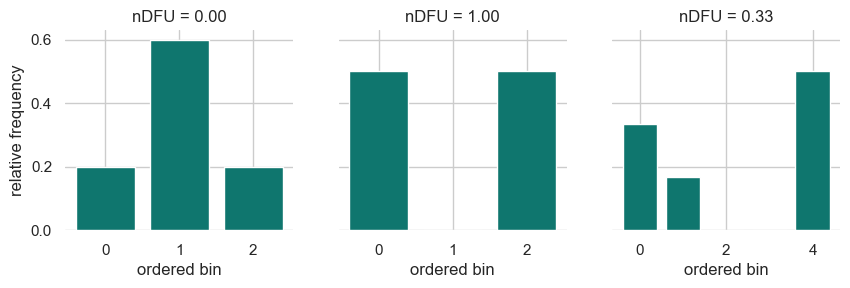

In [2]:
#@title Tiny nDFU examples
ndfu_examples = pd.DataFrame(
    {
        "description": ["one central peak", "two separated poles", "ratings split between low and high"],
        "ratings_or_histogram": [[0.2, 0.6, 0.2], [0.5, 0.0, 0.5], [1, 1, 2, 5, 5, 5]],
    }
)

def score_example(row):
    values = row["ratings_or_histogram"]
    if row["description"] == "ratings split between low and high":
        hist = pdf(values, SCALE)
    else:
        hist = values
    return pd.Series({"histogram": np.asarray(hist), "nDFU": dfu(hist)})

ndfu_examples = pd.concat([ndfu_examples, ndfu_examples.apply(score_example, axis=1)], axis=1)
display(ndfu_examples)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.6), sharey=True)
for ax, row in zip(axes, ndfu_examples.itertuples()):
    ax.bar(range(len(row.histogram)), row.histogram, color="#0f766e")
    ax.set_title(f"nDFU = {row.nDFU:.2f}")
    ax.set_xlabel("ordered bin")
axes[0].set_ylabel("relative frequency")
sns.despine(fig=fig, left=True, bottom=True)
show_or_close(fig)


## 2. The public class docstring

The class docstring is the compact API contract. It names the expected dataframe inputs, important columns, threshold behavior, optional custom label function, and model factory.

In [3]:
#@title Inspect the class docstring
print(inspect.getdoc(UnimodalLearner))


Prepare and train binary, reduced, and K+1 models from annotations.

Parameters
----------
train, dev, test : pandas.DataFrame
    Data splits. Each split must contain ``scores_col``. Model-fitting
    methods also require either ``feature_cols`` or a ``bert`` column.
feature_cols : sequence of str, optional
    Numeric feature columns used for model training. If omitted, a ``bert``
    column containing vector embeddings is used for compatibility with the
    original application notebook.
scores_col : str, default="scores"
    Column containing per-item ordinal annotations.
scale : sequence, default=SCALE10
    Ordered annotation scale passed to :func:`ndfu.pdf`.
threshold : float, default=0.0
    Items with ``DFU > threshold`` are assigned to ``kplus_label``.
ordinary_label_func : callable, optional
    Function mapping a sequence of scores to an ordinary class label. If
    omitted, scores below the middle of ``scale`` vote for
    ``positive_label``; otherwise they vote for ``nega

## 3. A tiny dataset

Each row below is one item. `scores` contains ordinal annotations from multiple annotators. The two feature columns are deliberately simple:

- `x_position` separates ordinary toxic-like and civil-like examples.
- `x_disagreement` helps identify pole-like examples.

The last three rows are designed to be pole-like: annotators split between low and high ratings.

In [4]:
#@title Build toy data
items = pd.DataFrame(
    {
        "item_id": ["t1", "t2", "t3", "c1", "c2", "c3", "p1", "p2", "p3"],
        "x_position": [-2.2, -1.7, -1.2, 1.1, 1.7, 2.2, -0.2, 0.0, 0.3],
        "x_disagreement": [-0.9, -0.6, -0.4, -0.5, -0.7, -0.4, 1.2, 1.4, 1.1],
        "scores": [
            [1, 1, 1, 2, 2, 2],
            [1, 1, 1, 1, 2, 2],
            [1, 1, 2, 2, 2, 3],
            [3, 4, 4, 5, 5, 5],
            [4, 4, 4, 5, 5, 5],
            [3, 4, 5, 5, 5, 5],
            [1, 1, 1, 5, 5, 5],
            [1, 1, 5, 5, 5, 5],
            [1, 1, 2, 5, 5, 5],
        ],
    }
)

display(items)


,item_id,x_position,x_disagreement,scores
0,t1,-2.2,-0.9,"[1, 1, 1, 2, 2, 2]"
1,t2,-1.7,-0.6,"[1, 1, 1, 1, 2, 2]"
2,t3,-1.2,-0.4,"[1, 1, 2, 2, 2, 3]"
3,c1,1.1,-0.5,"[3, 4, 4, 5, 5, 5]"
4,c2,1.7,-0.7,"[4, 4, 4, 5, 5, 5]"
5,c3,2.2,-0.4,"[3, 4, 5, 5, 5, 5]"
6,p1,-0.2,1.2,"[1, 1, 1, 5, 5, 5]"
7,p2,0.0,1.4,"[1, 1, 5, 5, 5, 5]"
8,p3,0.3,1.1,"[1, 1, 2, 5, 5, 5]"


## 4. Initialization and automatic annotation

When initialized, the learner copies each dataframe and adds four columns:

- `HIST`: relative-frequency vector from `pdf(scores, scale)`
- `DFU`: nDFU score from `dfu(HIST)`
- `binary_target`: ordinary label, here `toxic` or `civil`
- `kplus_target`: `k+1` for high-nDFU examples, otherwise the ordinary label

For a 1-5 scale, the default ordinary-label rule is: ratings below `3` vote for `toxic`; otherwise the item is `civil`.

In [5]:
#@title Initialize UnimodalLearner
train, test = train_test_split(items, test_size=0.33, random_state=7)
learner = UnimodalLearner(
    train,
    test=test,
    feature_cols=FEATURE_COLS,
    scale=SCALE,
    threshold=0.0,
)

columns = ["item_id", "scores", "HIST", "DFU", "binary_target", "kplus_target"]
display(learner.train[columns].sort_values("item_id"))


,item_id,scores,HIST,DFU,binary_target,kplus_target
3,c1,"[3, 4, 4, 5, 5, 5]","[0.0, 0.0, 0.16666666666666666, 0.333333333333...",0.000000,civil,civil
4,c2,"[4, 4, 4, 5, 5, 5]","[0.0, 0.0, 0.0, 0.5, 0.5]",0.000000,civil,civil
5,c3,"[3, 4, 5, 5, 5, 5]","[0.0, 0.0, 0.16666666666666666, 0.166666666666...",0.000000,civil,civil
6,p1,"[1, 1, 1, 5, 5, 5]","[0.5, 0.0, 0.0, 0.0, 0.5]",1.000000,toxic,k+1
8,p3,"[1, 1, 2, 5, 5, 5]","[0.3333333333333333, 0.16666666666666666, 0.0,...",0.333333,toxic,k+1
1,t2,"[1, 1, 1, 1, 2, 2]","[0.6666666666666666, 0.3333333333333333, 0.0, ...",0.000000,toxic,toxic


## 5. Ordinary labels

`ordinary_label(scores)` gives the non-K+1 label. You can use the default majority-style rule, or pass `ordinary_label_func` to the constructor when your ordinary task has different labels.

In [6]:
#@title ordinary_label examples
examples = pd.DataFrame(
    {
        "scores": [[1, 1, 2, 2, 3], [3, 4, 4, 5, 5], [1, 1, 5, 5, 5]],
    }
)
examples["ordinary_label"] = examples.scores.apply(learner.ordinary_label)
examples["hist"] = examples.scores.apply(lambda scores: pdf(scores, SCALE))
examples["ndfu"] = examples["hist"].apply(dfu)
display(examples)
print(inspect.getdoc(UnimodalLearner.ordinary_label))


,scores,ordinary_label,hist,ndfu
0,"[1, 1, 2, 2, 3]",toxic,"[0.4, 0.4, 0.2, 0.0, 0.0]",0.000000
1,"[3, 4, 4, 5, 5]",civil,"[0.0, 0.0, 0.2, 0.4, 0.4]",0.000000
2,"[1, 1, 5, 5, 5]",civil,"[0.4, 0.0, 0.0, 0.0, 0.6]",0.666667


Return the ordinary, non-K+1 label for an annotation list.


## 6. K+1 labels and thresholds

`make_kplus_label(score, scores)` applies the modeling decision. If the nDFU score is above the threshold, the item becomes `k+1`; otherwise it keeps its ordinary label.

`label_with_threshold(frame, threshold)` lets you explore how strict the K+1 rule should be without rebuilding the learner.

In [7]:
#@title Threshold behavior
thresholds = [0.0, 0.25, 0.50, 0.75, 1.0]
threshold_table = pd.DataFrame({
    "threshold": thresholds,
    "kplus_count": [
        (learner.label_with_threshold(learner.train, threshold) == learner.kplus_label).sum()
        for threshold in thresholds
    ],
})
display(threshold_table)
print(inspect.getdoc(UnimodalLearner.make_kplus_label))
print(inspect.getdoc(UnimodalLearner.label_with_threshold))


,threshold,kplus_count
0,0.00,2
1,0.25,2
2,0.50,1
3,0.75,1
4,1.00,0


Return ``kplus_label`` for high-nDFU items, otherwise ordinary label.
Return K+1 labels for ``frame`` using a custom nDFU threshold.


## 7. Feature extraction

`features(frame)` returns the matrix passed into classifiers. For new code, pass explicit `feature_cols`. For compatibility with the original application notebook, the learner can also read a `bert` column containing embedding vectors.

In [8]:
#@title Feature matrix
X = learner.features(learner.train)
print("Feature matrix shape:", X.shape)
print("First rows:")
print(X[:3])
print(inspect.getdoc(UnimodalLearner.features))


Feature matrix shape: (6, 2)
First rows:
[[ 0.3  1.1]
 [ 2.2 -0.4]
 [ 1.1 -0.5]]
Return model features from explicit columns or a BERT-vector column.


## 8. Training methods

The learner exposes three model-building methods:

- `fit_binary_baseline()`: train `civil` vs. `toxic` using all training examples.
- `fit_unimodal_only_baseline()`: remove high-nDFU examples, then train `civil` vs. `toxic`.
- `fit_kplus_model()`: train `civil`, `toxic`, and `k+1` jointly.

The default estimator is scikit-learn logistic regression. You can pass `estimator_factory` if you want another classifier.

In [9]:
#@title Fit the three model types
binary_model = learner.fit_binary_baseline()
clean_model = learner.fit_unimodal_only_baseline()
kplus_model = learner.fit_kplus_model()

print("binary classes:", list(binary_model.classes_))
print("unimodal-only classes:", list(clean_model.classes_))
print("K+1 classes:", list(kplus_model.classes_))
print("removed high-nDFU examples:", learner.removed_train_size_)
print(inspect.getdoc(UnimodalLearner.fit_binary_baseline))
print(inspect.getdoc(UnimodalLearner.fit_unimodal_only_baseline))
print(inspect.getdoc(UnimodalLearner.fit_kplus_model))


binary classes: ['civil', 'toxic']
unimodal-only classes: ['civil', 'toxic']
K+1 classes: ['civil', 'k+1', 'toxic']
removed high-nDFU examples: 2
Train a binary model on all training examples.
Train a binary model after removing high-nDFU training examples.
Train a model on ordinary labels plus the K+1 class.


## 9. Ordinary predictions from a K+1 model

Sometimes you train a K+1 model but evaluate only on ordinary low-nDFU examples. `binary_predictions_from_kplus(frame)` mirrors the application notebook: it ignores the `k+1` probability and chooses between the ordinary labels.

In [10]:
#@title Ignore K+1 probability for ordinary predictions
ordinary_test = learner.test[learner.test.DFU == 0]
if ordinary_test.empty:
    ordinary_test = learner.test

gold = ordinary_test.binary_target
baseline_pred = learner.binary_model.predict(learner.features(ordinary_test))
kplus_binary_pred = learner.binary_predictions_from_kplus(ordinary_test)

scores = pd.DataFrame(
    [
        {"model": "binary baseline", "macro_f1": f1_score(gold, baseline_pred, average="macro")},
        {"model": "K+1 model, k+1 ignored", "macro_f1": f1_score(gold, kplus_binary_pred, average="macro")},
    ]
)
display(scores)
print("K+1-as-binary predictions:", list(kplus_binary_pred))
print(inspect.getdoc(UnimodalLearner.binary_predictions_from_kplus))


,model,macro_f1
0,binary baseline,1.0
1,"K+1 model, k+1 ignored",1.0


K+1-as-binary predictions: ['toxic', 'toxic']
Predict ordinary labels from a K+1 model by ignoring K+1 probability.


## 10. Custom ordinary labels

The constructor accepts `ordinary_label_func` for domains where ordinary labels are not `civil` and `toxic`. The function receives the raw annotation list and returns an ordinary class label. High-nDFU examples can still be routed to `k+1`.

In [11]:
#@title Custom ordinary label function
def sentiment_label(scores):
    return "negative" if np.mean(scores) < 3 else "positive"

custom = UnimodalLearner(
    train,
    test=test,
    feature_cols=FEATURE_COLS,
    scale=SCALE,
    ordinary_label_func=sentiment_label,
    positive_label="negative",
    negative_label="positive",
    threshold=0.0,
)

display(custom.train[["item_id", "scores", "DFU", "binary_target", "kplus_target"]].sort_values("item_id"))


,item_id,scores,DFU,binary_target,kplus_target
3,c1,"[3, 4, 4, 5, 5, 5]",0.000000,positive,positive
4,c2,"[4, 4, 4, 5, 5, 5]",0.000000,positive,positive
5,c3,"[3, 4, 5, 5, 5, 5]",0.000000,positive,positive
6,p1,"[1, 1, 1, 5, 5, 5]",1.000000,positive,k+1
8,p3,"[1, 1, 2, 5, 5, 5]",0.333333,positive,k+1
1,t2,"[1, 1, 1, 1, 2, 2]",0.000000,negative,negative


## 11. Unit-test-style checks

The package also has repository-level tests, but notebooks benefit from local checks too. The cell below verifies the important contracts in this tutorial:

- annotation columns exist,
- high-nDFU examples become `k+1`,
- thresholding can remove the K+1 class,
- all three model types fit,
- K+1 predictions can be reduced back to ordinary labels.

In [12]:
#@title Run notebook-local unit tests
def test_annotation_columns():
    required = {"HIST", "DFU", "binary_target", "kplus_target"}
    assert required.issubset(learner.train.columns)


def test_kplus_labeling():
    high = learner.train[learner.train.DFU > 0]
    assert not high.empty
    assert set(high.kplus_target) == {learner.kplus_label}


def test_threshold_can_disable_kplus():
    labels = learner.label_with_threshold(learner.train, threshold=1.0)
    assert (labels == learner.kplus_label).sum() == 0


def test_models_are_fitted():
    assert set(learner.binary_model.classes_) == {"civil", "toxic"}
    assert set(learner.clean_binary_model.classes_) == {"civil", "toxic"}
    assert set(learner.kplus_model.classes_) == {"civil", "k+1", "toxic"}


def test_binary_predictions_from_kplus():
    preds = learner.binary_predictions_from_kplus(learner.train)
    assert preds.shape == (len(learner.train),)
    assert set(np.unique(preds)).issubset({"civil", "toxic"})


tests = [
    test_annotation_columns,
    test_kplus_labeling,
    test_threshold_can_disable_kplus,
    test_models_are_fitted,
    test_binary_predictions_from_kplus,
]

for test in tests:
    test()

pd.DataFrame({"test": [test.__name__ for test in tests], "status": "passed"})


,test,status
0,test_annotation_columns,passed
1,test_kplus_labeling,passed
2,test_threshold_can_disable_kplus,passed
3,test_models_are_fitted,passed
4,test_binary_predictions_from_kplus,passed


## Takeaway

`UnimodalLearner` turns nDFU from a measurement into a modeling workflow. It makes the K+1 choice explicit: ordinary examples keep ordinary labels, while structured disagreement gets a separate class that downstream models can learn.